# Attention Mechanisms — TensorFlow Pipeline

## Model: Seq2Seq with Bahdanau Attention (EN→ES Translation)

- **Dataset**: Tatoeba EN→ES — 114,478 train / 14,309 val / 14,311 test
- **Task**: Translate English to Spanish
- **Variant**: Bahdanau (additive) — best performer from PyTorch exploration
- **Framework comparison**: Confirms PyTorch findings with TF-native implementation

## Pipeline: 1-5 steps

1. Setup — imports, constants, data loading, vocab
2. Model — Encoder + Bahdanau Attention + Decoder + Training
3. Evaluation — Test BLEU, sample translations, attention heatmap
4. Benchmarks — Inference speed, model size, training summary
5. Save — Results dict, metrics.json, cross-framework comparison

In [1]:
# Step 1: Setup

import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../..'))
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison
from utils.attention_utils import compute_bleu
from utils.visualization import plot_attention_heatmap

# Constants
FRAMEWORK = 'TensorFlow'
RANDOM_STATE = 113
EMBED_DIM = 256
HIDDEN_DIM = 512
BATCH_SIZE = 64
LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
MAX_EPOCHS = 30
PATIENCE = 5

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# GPU check
print("=" * 60)
print("ATTENTION MECHANISMS — TensorFlow Pipeline")
print("=" * 60)
print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus[0].name if gpus else 'None'}")
if gpus:
    print(f"  {tf.test.gpu_device_name()}")

# Load preprocessed data
DATA_DIR = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/processed/attention'

train_src = np.load(os.path.join(DATA_DIR, 'src_train.npy'))
train_tgt = np.load(os.path.join(DATA_DIR, 'tgt_train.npy'))
val_src = np.load(os.path.join(DATA_DIR, 'src_val.npy'))
val_tgt = np.load(os.path.join(DATA_DIR, 'tgt_val.npy'))
test_src = np.load(os.path.join(DATA_DIR, 'src_test.npy'))
test_tgt = np.load(os.path.join(DATA_DIR, 'tgt_test.npy'))

with open(os.path.join(DATA_DIR, 'src_vocab.json'), 'r') as f:
    src_word2idx = json.load(f)
with open(os.path.join(DATA_DIR, 'tgt_vocab.json'), 'r') as f:
    tgt_word2idx = json.load(f)
with open(os.path.join(DATA_DIR, 'src_vocab_inv.json'), 'r') as f:
    src_idx2word = json.load(f)
with open(os.path.join(DATA_DIR, 'tgt_vocab_inv.json'), 'r') as f:
    tgt_idx2word = json.load(f)

SRC_VOCAB_SIZE = len(src_word2idx)
TGT_VOCAB_SIZE = len(tgt_word2idx)
MAX_LENGTH = train_src.shape[1]

# Special token indices
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2

print(f"\nData loaded:")
print(f"  Train: {train_src.shape[0]:,} pairs")
print(f"  Val:   {val_src.shape[0]:,} pairs")
print(f"  Test:  {test_src.shape[0]:,} pairs")
print(f"  Source vocab: {SRC_VOCAB_SIZE:,}")
print(f"  Target vocab: {TGT_VOCAB_SIZE:,}")
print(f"  Max length: {MAX_LENGTH}")

# TF Dataset — batched and shuffled
train_dataset = tf.data.Dataset.from_tensor_slices((train_src, train_tgt))
train_dataset = train_dataset.shuffle(len(train_src), seed=RANDOM_STATE).batch(BATCH_SIZE, drop_remainder=True)

# Helper to decode token indices back to words
def decode_tokens(token_ids, idx2word):
    tokens = []
    for idx in token_ids:
        word = idx2word.get(str(int(idx)), '<UNK>')
        if word == '<EOS>':
            break
        if word not in ('<PAD>', '<SOS>'):
            tokens.append(word)
    return tokens

print(f"\nDataset: {len(train_dataset)} batches of {BATCH_SIZE}")
print(f"  Ready for training")

I0000 00:00:1775511228.023932    5312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775511228.052635    5312 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775511228.737580    5312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


ATTENTION MECHANISMS — TensorFlow Pipeline
TensorFlow: 2.21.0
GPU: /physical_device:GPU:0
  /device:GPU:0

Data loaded:
  Train: 114,478 pairs
  Val:   14,309 pairs
  Test:  14,311 pairs
  Source vocab: 10,004
  Target vocab: 10,004
  Max length: 20


I0000 00:00:1775511229.671026    5312 gpu_device.cc:2043] Created device /device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1775511229.769333    5312 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9



Dataset: 1788 batches of 64
  Ready for training


In [2]:
# Step 2: Bahdanau Attention — Encoder + Decoder + Training
"""
TF-native implementation of the same Bahdanau architecture from PyTorch.
Uses tf.keras layers with a custom tf.GradientTape training loop —
Keras model.fit() doesn't support teacher forcing with per-step decoding.

Architecture identical to PT:
  - Bidirectional GRU encoder (outputs: batch, src_len, hidden*2)
  - Additive attention: score = V·tanh(W1·s + W2·h)
  - Context computed BEFORE GRU step (pre-attention)
  - GRU input: [embedding; context_1024]

Note: reset_after=False on GRU layers forces the non-CuDNN kernel,
required for WSL2 where cuDNN version may not match TF expectations.
"""
print("=" * 60)
print("[2/5] BAHDANAU (ADDITIVE) ATTENTION")
print("=" * 60)


class Encoder(tf.keras.Model):
    """Bidirectional GRU encoder — shared architecture with PyTorch."""

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim,
                                                    mask_zero=False)
        self.gru = tf.keras.layers.Bidirectional(
            tf.keras.layers.GRU(hidden_dim, return_sequences=True,
                                return_state=True, reset_after=False),
            merge_mode='concat'
        )
        self.fc_hidden = tf.keras.layers.Dense(hidden_dim, activation='tanh')

    def call(self, src, training=False):
        embedded = self.embedding(src)
        outputs, fwd_state, bwd_state = self.gru(embedded, training=training)
        combined = tf.concat([fwd_state, bwd_state], axis=1)
        hidden = self.fc_hidden(combined)
        hidden = tf.expand_dims(hidden, axis=0)
        return outputs, hidden


class BahdanauAttention(tf.keras.layers.Layer):
    """Additive attention: score = V·tanh(W1·s + W2·h)"""

    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(hidden_dim, use_bias=False)
        self.W2 = tf.keras.layers.Dense(hidden_dim, use_bias=False)
        self.V = tf.keras.layers.Dense(1, use_bias=False)

    def call(self, decoder_hidden, encoder_outputs):
        query = tf.expand_dims(self.W1(decoder_hidden), 1)
        keys = self.W2(encoder_outputs)
        energy = tf.nn.tanh(query + keys)
        scores = tf.squeeze(self.V(energy), axis=-1)
        attn_weights = tf.nn.softmax(scores, axis=1)
        context = tf.squeeze(
            tf.matmul(tf.expand_dims(attn_weights, 1), encoder_outputs),
            axis=1)
        return context, attn_weights


class DecoderBahdanau(tf.keras.Model):
    """Decoder with Bahdanau attention — context fed into GRU."""

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim,
                                                    mask_zero=False)
        self.attention = BahdanauAttention(hidden_dim)
        self.gru = tf.keras.layers.GRU(hidden_dim, return_state=True,
                                        reset_after=False)
        self.fc_out = tf.keras.layers.Dense(vocab_size)

    def call(self, tgt_token, hidden, encoder_outputs, training=False):
        embedded = self.embedding(tgt_token)
        context, attn_weights = self.attention(
            tf.squeeze(hidden, axis=0), encoder_outputs)
        gru_input = tf.expand_dims(
            tf.concat([embedded, context], axis=1), 1)
        output, state = self.gru(gru_input,
                                  initial_state=tf.squeeze(hidden, axis=0),
                                  training=training)
        prediction = self.fc_out(output)
        hidden = tf.expand_dims(state, 0)
        return prediction, hidden, attn_weights


# Build models
encoder = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder = DecoderBahdanau(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True,
                                                         reduction='none')


def compute_loss(real, pred):
    """Cross-entropy loss ignoring padding tokens. Safe against all-PAD batches."""
    mask = tf.cast(real != PAD_IDX, dtype=tf.float32)
    loss = loss_fn(real, pred)
    masked_loss = loss * mask
    total_mask = tf.reduce_sum(mask)
    # Avoid NaN from dividing by zero when entire sequence is padding
    return tf.cond(total_mask > 0,
                   lambda: tf.reduce_sum(masked_loss) / total_mask,
                   lambda: 0.0)


@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, None], dtype=tf.int32),
    tf.TensorSpec(shape=[None, None], dtype=tf.int32)
])
def train_step(src_batch, tgt_batch):
    """Single training step with teacher forcing via tf.cond."""
    tgt_len = tf.shape(tgt_batch)[1]

    with tf.GradientTape() as tape:
        encoder_outputs, hidden = encoder(src_batch, training=True)
        decoder_input = tf.cast(tgt_batch[:, 0], tf.int32)

        total_loss = 0.0
        for t in tf.range(1, tgt_len):
            prediction, hidden, _ = decoder(
                decoder_input, hidden, encoder_outputs, training=True)
            total_loss += compute_loss(tgt_batch[:, t], prediction)

            # Teacher forcing with tf.cond (graph-safe branching)
            teacher = tf.cast(tgt_batch[:, t], tf.int32)
            predicted = tf.cast(tf.argmax(prediction, axis=1), tf.int32)
            decoder_input = tf.cond(
                tf.random.uniform(()) < TEACHER_FORCING_RATIO,
                lambda: teacher,
                lambda: predicted)

        avg_loss = total_loss / tf.cast(tgt_len - 1, tf.float32)

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(avg_loss, variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    optimizer.apply_gradients(zip(gradients, variables))

    return avg_loss


def greedy_decode(src, max_len=MAX_LENGTH):
    """Greedy decode a batch of source sentences."""
    batch_size = src.shape[0]
    encoder_outputs, hidden = encoder(src, training=False)

    decoder_input = tf.fill([batch_size], SOS_IDX)
    translations = np.zeros((batch_size, max_len), dtype=np.int32)
    translations[:, 0] = SOS_IDX

    for t in range(1, max_len):
        prediction, hidden, _ = decoder(
            decoder_input, hidden, encoder_outputs, training=False)
        top1 = tf.cast(tf.argmax(prediction, axis=1), tf.int32)
        translations[:, t] = top1.numpy()
        decoder_input = top1

    return translations


def evaluate_bleu(src, tgt, batch_size=256):
    """Compute corpus BLEU on a dataset."""
    all_refs = []
    all_hyps = []

    for i in range(0, len(src), batch_size):
        src_batch = src[i:i+batch_size]
        tgt_batch = tgt[i:i+batch_size]
        translations = greedy_decode(src_batch)

        for j in range(len(src_batch)):
            ref = decode_tokens(tgt_batch[j], tgt_idx2word)
            hyp = decode_tokens(translations[j], tgt_idx2word)
            all_refs.append([ref])
            all_hyps.append(hyp)

    return compute_bleu(all_refs, all_hyps)


# Force model build with non-zero tokens (zeros = all PAD → would cause NaN)
dummy_src = tf.ones((1, MAX_LENGTH), dtype=tf.int32) * SOS_IDX
dummy_tgt = tf.ones((1, MAX_LENGTH), dtype=tf.int32) * SOS_IDX
_ = train_step(dummy_src, dummy_tgt)

n_params = (sum(np.prod(v.shape) for v in encoder.trainable_variables) +
            sum(np.prod(v.shape) for v in decoder.trainable_variables))

print(f"\n  Seq2Seq + Bahdanau Attention (TensorFlow)")
print(f"  Parameters: {n_params:,}")
print(f"  Training (max {MAX_EPOCHS} epochs, patience={PATIENCE})...")

best_bleu = 0.0
patience_counter = 0
train_losses = []
val_bleus = []
best_encoder_weights = None
best_decoder_weights = None

with track_performance(gpu=True) as perf:
    for epoch in range(MAX_EPOCHS):
        epoch_loss = 0.0
        n_batches = 0

        for src_batch, tgt_batch in train_dataset:
            loss = train_step(src_batch, tgt_batch)
            epoch_loss += loss.numpy()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)

        # Validate with BLEU
        val_bleu = evaluate_bleu(val_src, val_tgt)
        val_bleus.append(val_bleu)

        if val_bleu > best_bleu:
            best_bleu = val_bleu
            patience_counter = 0
            best_encoder_weights = [v.numpy().copy() for v in encoder.trainable_variables]
            best_decoder_weights = [v.numpy().copy() for v in decoder.trainable_variables]
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch [{epoch+1:>3}/{MAX_EPOCHS}] | "
                  f"Loss: {avg_loss:.4f} | Val BLEU: {val_bleu:.4f} | "
                  f"Best: {best_bleu:.4f}")

        if patience_counter >= PATIENCE:
            print(f"    Early stop at epoch {epoch+1}")
            break

# Restore best model
if best_encoder_weights:
    for v, w in zip(encoder.trainable_variables, best_encoder_weights):
        v.assign(w)
    for v, w in zip(decoder.trainable_variables, best_decoder_weights):
        v.assign(w)

epochs_trained = len(train_losses)
print(f"\n  Training time: {perf['time']:.1f}s")
print(f"  GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"  Best val BLEU: {best_bleu:.4f}")
print(f"  Epochs: {epochs_trained}")

# Show sample translations
print(f"\n  Sample translations (Bahdanau — TF):")
print(f"  {'-'*50}")
sample_indices = [0, 100, 500, 1000, 5000]
sample_src = test_src[sample_indices]
sample_translations = greedy_decode(sample_src)

for i, idx in enumerate(sample_indices):
    en = decode_tokens(test_src[idx], src_idx2word)
    ref = decode_tokens(test_tgt[idx], tgt_idx2word)
    hyp = decode_tokens(sample_translations[i], tgt_idx2word)
    print(f"    EN:  {' '.join(en)}")
    print(f"    REF: {' '.join(ref)}")
    print(f"    HYP: {' '.join(hyp)}\n")

[2/5] BAHDANAU (ADDITIVE) ATTENTION

  Seq2Seq + Bahdanau Attention (TensorFlow)
  Parameters: 16,682,260
  Training (max 30 epochs, patience=5)...
    Epoch [  1/30] | Loss: 3.6900 | Val BLEU: 0.0029 | Best: 0.0029
    Epoch [  5/30] | Loss: 2.0212 | Val BLEU: 0.1588 | Best: 0.1588
    Epoch [ 10/30] | Loss: 1.2476 | Val BLEU: 0.2830 | Best: 0.2830
    Epoch [ 15/30] | Loss: 1.0141 | Val BLEU: 0.3100 | Best: 0.3100
    Epoch [ 20/30] | Loss: 0.8982 | Val BLEU: 0.3206 | Best: 0.3206
    Epoch [ 25/30] | Loss: 0.8119 | Val BLEU: 0.3284 | Best: 0.3284
    Epoch [ 30/30] | Loss: 0.7697 | Val BLEU: 0.3316 | Best: 0.3353

  Training time: 16692.0s
  GPU memory: 0.0 MB
  Best val BLEU: 0.3353
  Epochs: 30

  Sample translations (Bahdanau — TF):
  --------------------------------------------------
    EN:  everyone who knew him admired him .
    REF: todos los que le conocían le <UNK> .
    HYP: todo el mundo lo que lo <UNK> .

    EN:  i know all that .
    REF: yo sé todo eso .
    HYP: sé 

[3/5] EVALUATION

  Test BLEU: 0.3368
  Val BLEU:  0.3353

  Attention heatmap sentence (idx=1):
    EN:  don ' t let him press this button .
    REF: no le dejes pulsar este botón .
    HYP: no le <UNK> pulse este botón .


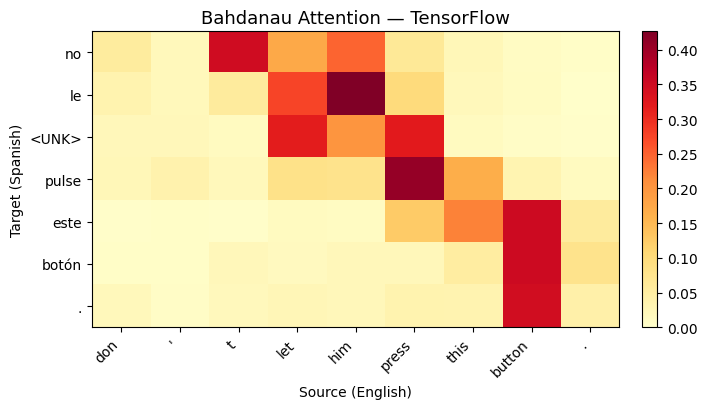


  Heatmap saved to results/bahdanau_attention_heatmap.png


In [3]:
# Step 3: Evaluation — Test BLEU + Attention Heatmap
print("=" * 60)
print("[3/5] EVALUATION")
print("=" * 60)

# Test BLEU
test_bleu = evaluate_bleu(test_src, test_tgt)
print(f"\n  Test BLEU: {test_bleu:.4f}")
print(f"  Val BLEU:  {best_bleu:.4f}")

# Attention heatmap — pick a medium-length sentence for clear visualization
# Decode one sentence and capture attention weights
def decode_with_attention(src_sentence):
    # Greedy decode a single sentence, returning tokens + attention matrix
    src_tensor = tf.expand_dims(src_sentence, 0)
    encoder_outputs, hidden = encoder(src_tensor, training=False)

    decoder_input = tf.constant([SOS_IDX])
    decoded_tokens = []
    attention_matrix = []

    for t in range(MAX_LENGTH):
        prediction, hidden, attn_weights = decoder(
            decoder_input, hidden, encoder_outputs, training=False)
        top1 = tf.cast(tf.argmax(prediction, axis=1), tf.int32)
        token_id = top1.numpy()[0]

        word = tgt_idx2word.get(str(token_id), '<UNK>')
        if word == '<EOS>':
            break
        if word not in ('<PAD>', '<SOS>'):
            decoded_tokens.append(word)
            attention_matrix.append(attn_weights.numpy()[0])

        decoder_input = top1

    return decoded_tokens, np.array(attention_matrix) if attention_matrix else None

# Find a good sentence (8-12 source tokens, non-trivial)
for idx in range(len(test_src)):
    src_tokens = decode_tokens(test_src[idx], src_idx2word)
    if 8 <= len(src_tokens) <= 12:
        heatmap_idx = idx
        break

src_tokens_hm = decode_tokens(test_src[heatmap_idx], src_idx2word)
ref_tokens_hm = decode_tokens(test_tgt[heatmap_idx], tgt_idx2word)
hyp_tokens_hm, attn_matrix = decode_with_attention(test_src[heatmap_idx])

print(f"\n  Attention heatmap sentence (idx={heatmap_idx}):")
print(f"    EN:  {' '.join(src_tokens_hm)}")
print(f"    REF: {' '.join(ref_tokens_hm)}")
print(f"    HYP: {' '.join(hyp_tokens_hm)}")

# Plot attention heatmap
if attn_matrix is not None:
    # Trim attention to actual source length
    src_len = len(src_tokens_hm)
    attn_trimmed = attn_matrix[:, :src_len]

    save_dir = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/15-attention/results'
    os.makedirs(save_dir, exist_ok=True)

    plot_attention_heatmap(
        attn_trimmed, src_tokens_hm, hyp_tokens_hm,
        title='Bahdanau Attention — TensorFlow',
        save_path=os.path.join(save_dir, 'bahdanau_attention_heatmap.png'))
    print(f"\n  Heatmap saved to results/bahdanau_attention_heatmap.png")

In [6]:
# Step 4: Performance Benchmarks
print("=" * 60)
print("[4/5] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Inference speed — translate single sentences
def predict_fn(src):
    return greedy_decode(src)

inf_results = track_inference(predict_fn, test_src[:1000], n_runs=3)

# Model size (encoder + decoder)
enc_size = get_model_size(encoder, framework='tensorflow')
dec_size = get_model_size(decoder, framework='tensorflow')

n_params = (sum(np.prod(v.shape) for v in encoder.trainable_variables) +
            sum(np.prod(v.shape) for v in decoder.trainable_variables))

print(f"\n  Bahdanau Attention — TensorFlow Benchmarks")
print(f"  {'-'*50}")
print(f"  Parameters:      {n_params:,}")
print(f"  Model size:      {(enc_size + dec_size) / (1024**2):.2f} MB")
print(f"  Training time:   {perf['time']:.1f}s ({epochs_trained} epochs)")
print(f"  GPU memory:      {perf['gpu_memory']:.1f} MB")
print(f"  Inference:       {inf_results['per_sample_us']:.2f} µs/sentence")
print(f"  Test BLEU:       {test_bleu:.4f}")

[4/5] PERFORMANCE BENCHMARKS

  Bahdanau Attention — TensorFlow Benchmarks
  --------------------------------------------------
  Parameters:      16,682,260
  Model size:      63.64 MB
  Training time:   16692.0s (30 epochs)
  GPU memory:      0.0 MB
  Inference:       398.61 µs/sentence
  Test BLEU:       0.3368


In [9]:
# Step 5: Save Results
print("=" * 60)
print("[5/5] SAVE RESULTS")
print("=" * 60)

save_dir = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/15-attention/results'

results = {
    'model': 'Attention (Bahdanau)',
    'framework': 'TensorFlow',
    'test_bleu': round(test_bleu, 4),
    'best_val_bleu': round(best_bleu, 4),
    'n_params': int(n_params),
    'training_time': round(perf['time'], 1),
    'epochs': epochs_trained,
    'inference_time_per_sample_us': round(inf_results['per_sample_us'], 2),
    'model_size_bytes': int(enc_size + dec_size),
    'peak_memory_mb': round(perf['gpu_memory'], 2),
    'best_variant': 'Bahdanau',
    'attention_type': 'Bahdanau (Additive)',
    'encoder': 'Bidirectional GRU',
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'teacher_forcing_ratio': TEACHER_FORCING_RATIO
}

save_results(results, save_dir=save_dir)
add_result('attention', results)
print_comparison('attention')

[5/5] SAVE RESULTS
    Results saved to: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/15-attention/results/metrics.json
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/attention.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: ATTENTION
Metric                                       PyTorch            TensorFlow
--------------------------------------------------------------------------
model                            Attention (Seq2Seq)  Attention (Bahdanau)
test_bleu                                     0.3803                0.3368
training_time                               16.2 min             278.2 min
inference_time_per_sample_us                21.59 µs             398.61 µs
model_size_bytes                            63.66 MB              63.64 MB
peak_memory_mb                             874.11 MB               0.00 MB
n_params                                    166868